## Navigo Denoising: Myofibroblast Trajectory

Developmental scRNA-seq data is inherently noisy. This tutorial shows how Navigo denoises a myofibroblast trajectory by ODE integration, then validates the result against ground-truth expression, pathway enrichment, and cell-type proportions.

**Steps:**
1. Denoise trajectory via ODE integration + KNN cell-type assignment
2. Compute per-day differential expression
3. Extract marker genes recovered by denoising
4. Test pathway enrichment (predicted vs observed)
5. Build marker, pathway, and trajectory display tables
6. Visualize all results

In [1]:
import gc, warnings
from pathlib import Path
import anndata, matplotlib.pyplot as plt, numpy as np, pandas as pd, torch
import navigo, navigo.tl, navigo.pl
from navigo.io import normalize_to_x
warnings.filterwarnings('ignore')
%config InlineBackend.figure_format = 'retina'

## Configuration

In [2]:
DATA_DIR       = Path("/scratch/users/steorra/analysis/26_yimin/data")
CHECKPOINT_DIR = Path("/scratch/users/steorra/analysis/26_yimin/checkpoints")
OUTPUT_DIR     = Path("/scratch/users/steorra/analysis/26_yimin/Navigo-release/docs/tutorials/outputs")
FULL_DATA       = DATA_DIR / 'interpolation' / 'mouse_embryogenesis_aggregated_full_hvg_4000.h5ad'
CKPT            = CHECKPOINT_DIR / 'interpolation' / 'myofibroblast_imputation_checkpoint_round6.pth'
MSIGDB_PATH     = DATA_DIR / 'interpolation' / 'msigdb_mouse_v2025_1.json'
CT_TO_TRAJ_JSON = DATA_DIR / 'interpolation' / 'ct_to_trajectory.json'
NOTEBOOK_OUT = OUTPUT_DIR / 'interpolation_myofibroblasts'
PRED_DIR  = NOTEBOOK_OUT / '00_model_inference'
DEG_DIR   = NOTEBOOK_OUT / '00_deg_results'
CASE_DIR  = NOTEBOOK_OUT / '00_case_cache'
for p in [PRED_DIR, DEG_DIR, CASE_DIR]:
    p.mkdir(parents=True, exist_ok=True)
CELL_TYPE = 'Myofibroblasts'; TARGET_DAY = 18.25; START_DAY = 8.5; STEP = 0.25
SOURCE_INDICES = list(range(22, 41)); SEED = 42
navigo.set_seed(SEED)

## Step 1: Denoise trajectory

For each time interval, integrate the ODE forward and assign cell types via KNN.

In [3]:
summary = navigo.tl.denoise_trajectory(
    FULL_DATA, CKPT, source_indices=SOURCE_INDICES, pred_dir=PRED_DIR, seed=SEED,
)
gc.collect(); torch.cuda.empty_cache() if torch.cuda.is_available() else None
summary

{'prediction_files_available': 19, 'prediction_files_expected': 19}

## Step 2: Compute per-day DEGs

In [4]:
adata_backed = anndata.read_h5ad(FULL_DATA, backed='r')
mask = (adata_backed.obs['cell_type'].astype(str) == CELL_TYPE).values
adata_ct = normalize_to_x(adata_backed[mask].to_memory())
del adata_backed; gc.collect()

0

In [5]:
ct_file = CELL_TYPE.replace('/', '_').replace(' ', '_')
saved = navigo.tl.compute_deg_by_day(adata_ct, DEG_DIR, file_prefix=f'{ct_file}_')
del adata_ct; gc.collect()
print(f'DEG tables: {len(saved)} days')

DEG tables: 36 days


## Step 3: Extract marker genes

Identify genes whose expression is recovered by denoising.

In [6]:
marker_df = navigo.tl.extract_denoising_markers(
    FULL_DATA, PRED_DIR, DEG_DIR, CELL_TYPE, TARGET_DAY, START_DAY, STEP,
    cache_dir=CASE_DIR,
)
marker_df

,gene,t_minus_0.25,t_center,t_plus_0.25,t_plus_0.5,t_pred
0,Cdkn1c,0.757490,0.197858,0.396096,0.262628,0.425791
1,Ckm,1.450371,0.699214,1.001154,0.730133,1.122515
2,ENSMUSG00000085981,0.589681,0.000000,0.021291,0.012323,0.207896
3,Klf17,0.039111,0.000000,0.000000,0.000000,0.012518
4,Tnnc2,1.323882,0.415867,0.751477,0.615662,0.870595
5,Tpm2,1.492836,0.677595,1.097514,0.871561,1.102887
6,Vwc2,1.246291,0.469402,0.759051,0.650579,0.829878


## Step 4: Pathway enrichment

Test GOBP pathways for enrichment in predicted vs observed cells.

In [7]:
shared_pathways_df = navigo.tl.denoising_pathway_enrichment(
    FULL_DATA, PRED_DIR, DEG_DIR, MSIGDB_PATH, CELL_TYPE, TARGET_DAY,
    START_DAY, STEP, cache_dir=CASE_DIR,
)
shared_pathways_df.head()

,pathway,pred_E18.25_pval,real_E18.0_pval,real_E18.5_pval,real_E18.25_pval,pred_E18.25_neg_log_pval,real_E18.0_neg_log_pval,real_E18.5_neg_log_pval,real_E18.25_neg_log_pval
0,SMALL MOLECULE METABOLIC PROCESS,0.712730,0.000066,0.006951,0.120146,0.147075,4.182304,2.157974,0.920291
1,SKELETAL MUSCLE CONTRACTION,0.059892,0.003762,0.602044,0.529710,1.222632,2.424553,0.220372,0.275962
2,REGULATION OF RESPONSE TO STRESS,0.734860,0.000614,0.000263,0.667197,0.133795,3.212101,3.579512,0.175746
3,REGULATION OF DEFENSE RESPONSE,NaN,0.000195,0.000103,0.153309,NaN,3.709901,3.986606,0.814432
4,ORGANIC ACID METABOLIC PROCESS,NaN,0.000287,0.000115,0.065869,NaN,3.541385,3.938671,1.181321


## Step 5a: Build marker expression table

In [8]:
marker_tables = navigo.tl.build_denoising_marker_table(
    FULL_DATA, PRED_DIR, CELL_TYPE, TARGET_DAY, START_DAY, STEP,
)
marker_tables['display_df']

,gene,t_minus_0.25,t_center,t_plus_0.25,t_plus_0.5,t_pred
0,Cdkn1c,0.757490,0.197858,0.396096,0.262628,0.425791
1,Synpo2,1.211313,0.413840,0.557402,0.499099,0.373312
2,Myf6,0.898255,0.153843,0.305768,0.179879,0.384003
3,Tnnc2,1.323882,0.415867,0.751477,0.615662,0.870595
4,Myog,0.596710,0.198418,0.306711,0.341662,0.299011
5,Aldoa,1.220162,0.332767,0.676658,0.331126,0.452666


## Step 5b: Build pathway plot table

In [9]:
pathway_plot_df = navigo.tl.build_denoising_pathway_table(shared_pathways_df)
pathway_plot_df

,pathway,pathway_short,Navigo,Noisy
0,SMALL MOLECULE METABOLIC PROCESS,Small Mol. Metab. Proc.,0.147075,0.920291
1,SKELETAL MUSCLE CONTRACTION,Skel. Muscle Contraction,1.222632,0.275962
2,REGULATION OF RESPONSE TO STRESS,Reg. Response Stress,0.133795,0.175746
3,REGULATION OF DEFENSE RESPONSE,Reg. Defense Response,0.000000,0.814432
4,ORGANIC ACID METABOLIC PROCESS,Organic Acid Metab. Proc.,0.000000,1.181321
5,MULTICELLULAR ORGANISMAL MOVEMENT,Multicell. Organ. Movement,1.145941,0.224959
6,LIPID METABOLIC PROCESS,Lipid Metab. Proc.,0.000000,2.520198


## Step 5c: Build trajectory proportion table

In [10]:
trajectory_df = navigo.tl.build_denoising_trajectory_table(
    FULL_DATA, PRED_DIR, CT_TO_TRAJ_JSON, CELL_TYPE,
)
trajectory_df.head()

,series,day_num,day_label,group,count,ratio,source
0,Noisy,14.00,E14.0,Myofibroblasts,111,0.246667,observed
1,Noisy,14.00,E14.0,Muscle prog.,100,0.222222,observed
2,Noisy,14.00,E14.0,Myoblasts,138,0.306667,observed
3,Noisy,14.00,E14.0,Myotubes,101,0.224444,observed
4,Noisy,14.25,E14.25,Myofibroblasts,120,0.286396,observed


## Step 6a: Trajectory proportions — Noisy

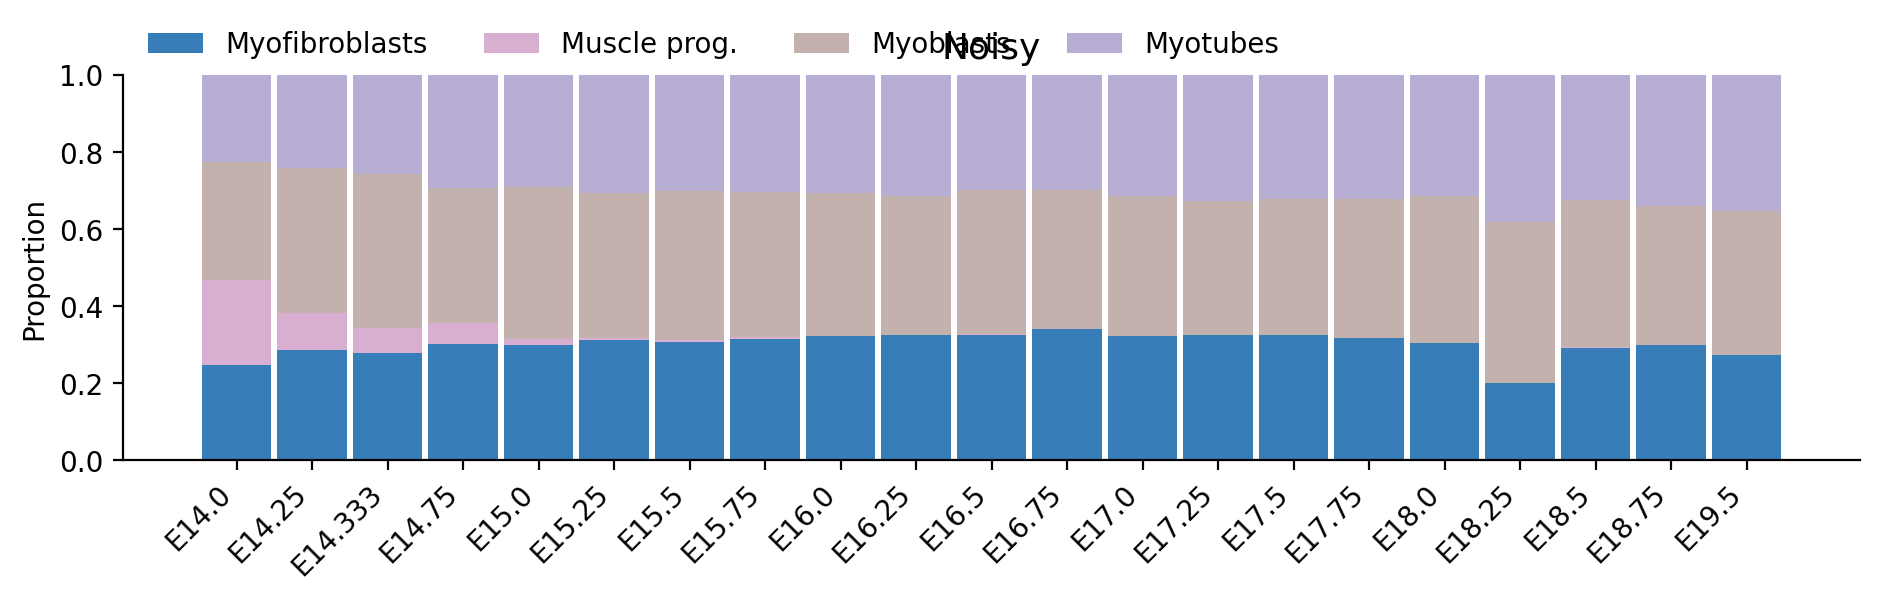

<Axes: title={'center': 'Noisy'}, ylabel='Proportion'>

In [11]:
traj_order  = ['Myofibroblasts', 'Muscle prog.', 'Myoblasts', 'Myotubes']
traj_colors = {'Myofibroblasts': '#377eb8', 'Muscle prog.': '#d8afd0',
                'Myoblasts': '#c3b1ae', 'Myotubes': '#b8add2'}
noisy = trajectory_df[trajectory_df['series'] == 'Noisy']
navigo.pl.stacked_bar(noisy, x_col='day_label', group_col='group', value_col='ratio',
                      group_order=traj_order, colors=traj_colors, title='Noisy', ylabel='Proportion')

## Step 6b: Trajectory proportions — Navigo

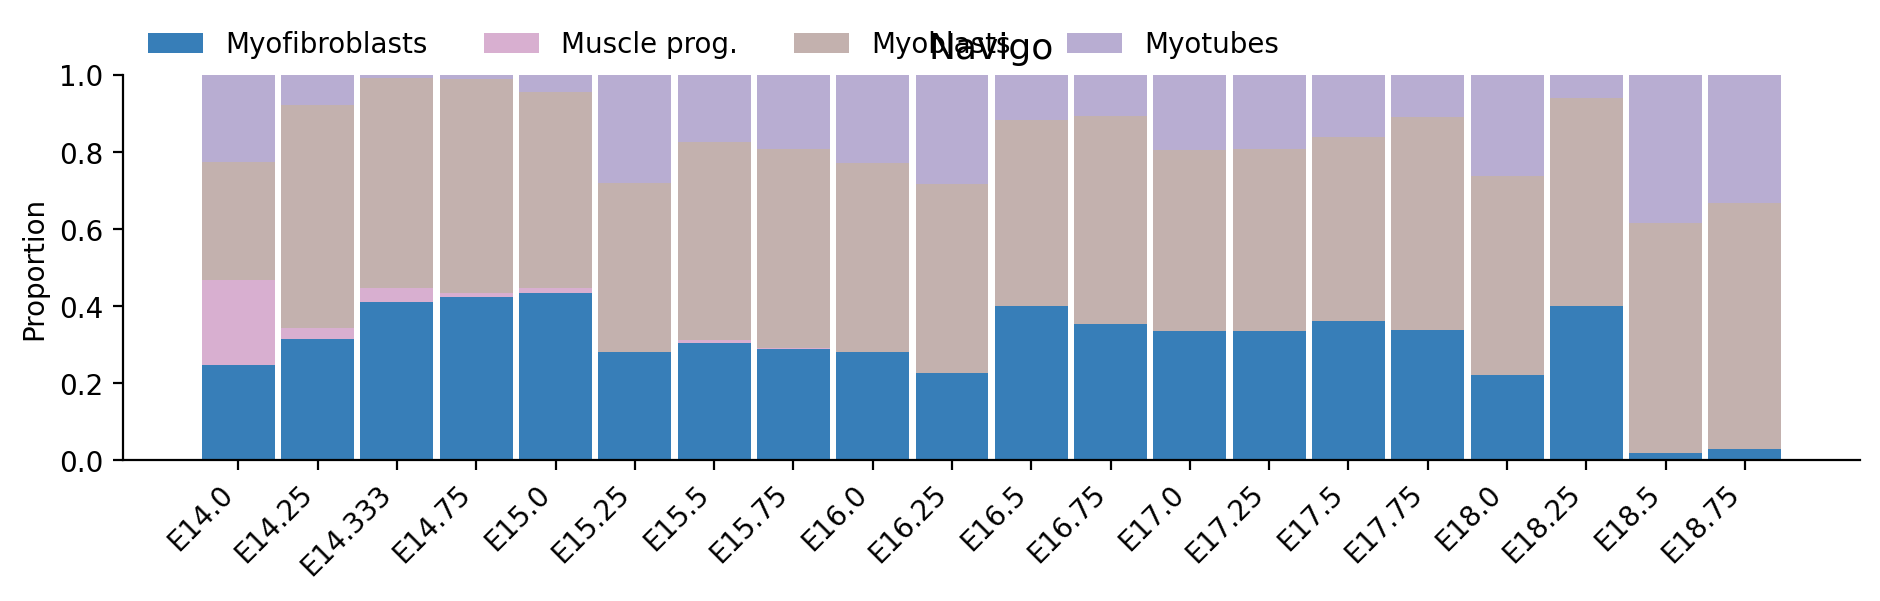

<Axes: title={'center': 'Navigo'}, ylabel='Proportion'>

In [12]:
nav = trajectory_df[trajectory_df['series'] == 'Navigo']
navigo.pl.stacked_bar(nav, x_col='day_label', group_col='group', value_col='ratio',
                      group_order=traj_order, colors=traj_colors, title='Navigo', ylabel='Proportion')

## Step 6c: Marker heatmaps

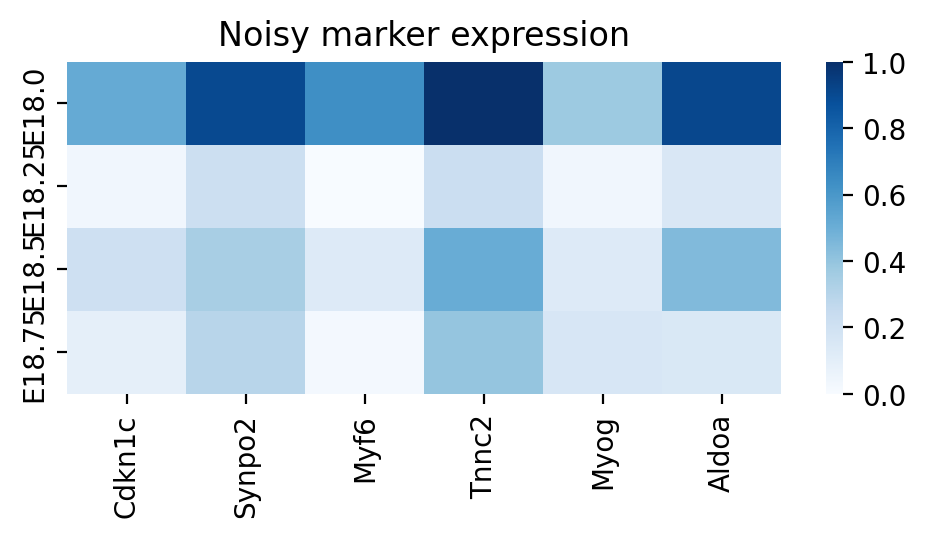

<Axes: title={'center': 'Noisy marker expression'}>

In [13]:
navigo.pl.expression_heatmap(marker_tables['noisy_scaled'], title='Noisy marker expression')

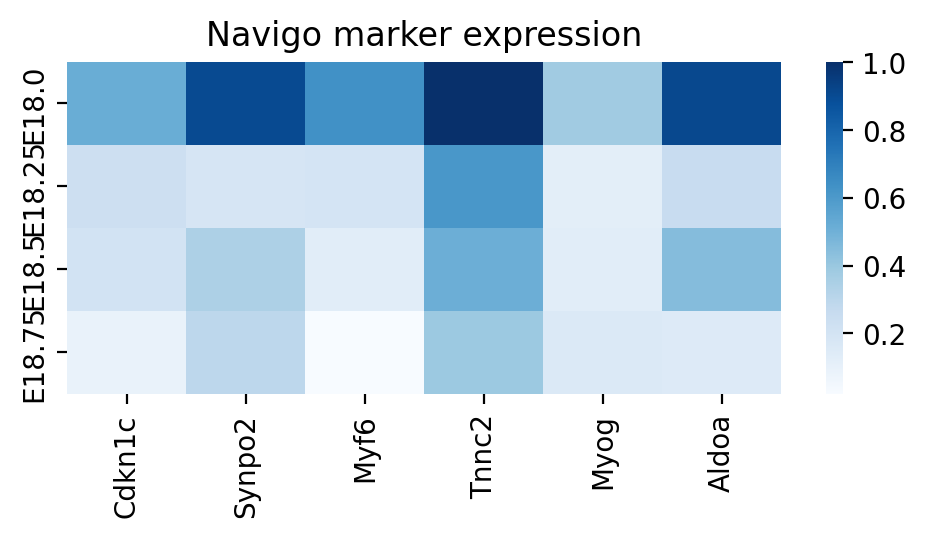

<Axes: title={'center': 'Navigo marker expression'}>

In [14]:
navigo.pl.expression_heatmap(marker_tables['navigo_scaled'], title='Navigo marker expression')

## Step 6d: Pathway enrichment comparison

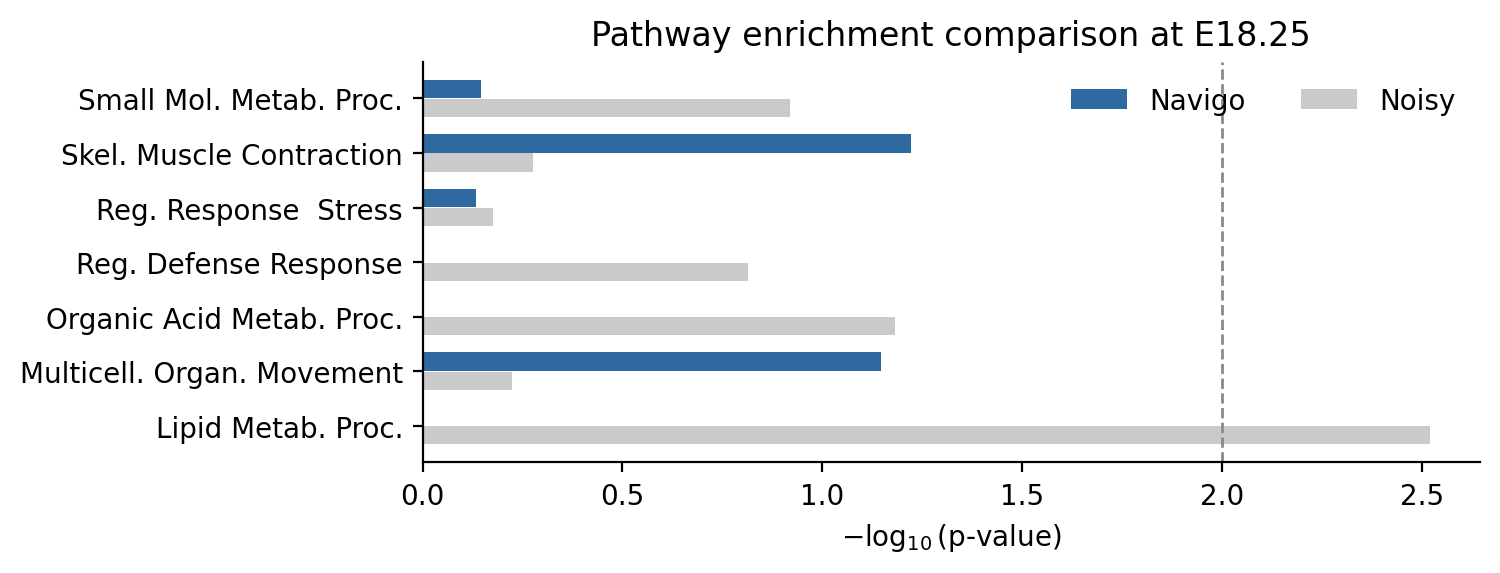

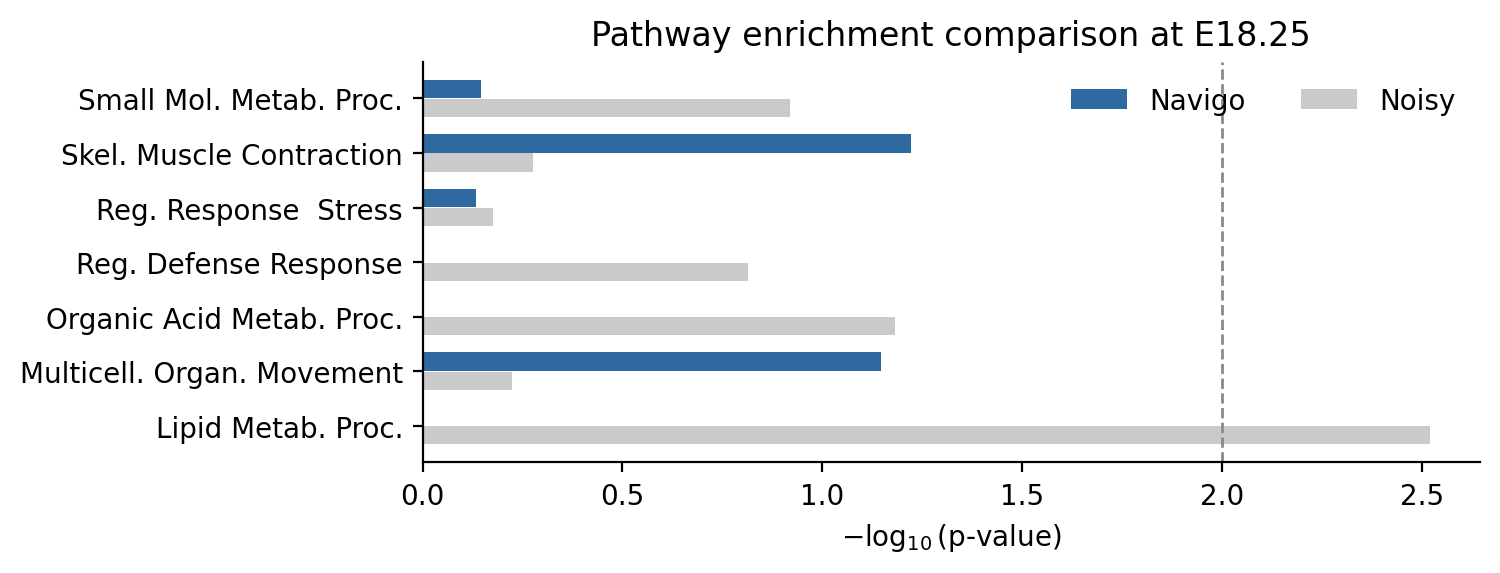

In [15]:
navigo.pl.grouped_barh(
    pathway_plot_df['pathway_short'],
    {'Navigo': pathway_plot_df['Navigo'], 'Noisy': pathway_plot_df['Noisy']},
    title='Pathway enrichment comparison at E18.25',
)